# Compare SSL vs Contrastive Embeddings

This notebook compares two types of DreaMS embeddings:
1. **SSL embeddings** - Pure pre-trained (from `ssl_model.ckpt`)
2. **Contrastive embeddings** - Fine-tuned with triplet loss (from `embedding_model.ckpt`)

We'll visualize both using UMAP to see how they differ in their clustering patterns.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from pacmap import PaCMAP
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

In [21]:
# Load data with both embeddings
data_path = Path('../data/processed/massspecgym_complete/ssl_embs/MassSpecGym_with_SSL_embeddings.parquet')
df = pd.read_parquet(data_path)

print(f"Total samples: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Total samples: 231,104
Columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'simulation_challenge', 'mol_weight', 'logp', 'tpsa', 'scaffold_id', 'murcko_scaffold', 'alkene', 'aromatic', 'hydroxyl', 'ketone', 'carboxylic_acid', 'amine_primary', 'amide', 'ester', 'nitrile', 'halide', 'phosphate', 'thiol', 'nitro', 'ecfp4', 'map4', 'fold', 'embedding', 'ssl_embedding']


## Extract Test Set

In [10]:
# Get test set
df_test = df[df['fold'] == 'test'].copy()
print(f"Test set size: {len(df_test):,}")

Test set size: 30,399


## Sample for Visualization

UMAP on 30k samples takes ~30 seconds. We'll use the same sample size for fair comparison.

In [11]:
# Sample for visualization (use all test data or sample if too large)
np.random.seed(42)
if len(df_test) > 30000:
    df_sample = df_test.sample(n=30000, random_state=42)
else:
    df_sample = df_test.copy()

print(f"Visualization sample size: {len(df_sample):,}")

Visualization sample size: 30,000


## Extract Both Embeddings

In [12]:
# Extract SSL embeddings (pure pre-trained)
ssl_embeddings = np.vstack(df_sample['ssl_embedding'].values)
print(f"SSL embeddings shape: {ssl_embeddings.shape}")
print(f"SSL embeddings - mean: {ssl_embeddings.mean():.4f}, std: {ssl_embeddings.std():.4f}")

# Extract Contrastive embeddings (fine-tuned)
contrastive_embeddings = np.vstack(df_sample['embedding'].values)
print(f"\nContrastive embeddings shape: {contrastive_embeddings.shape}")
print(f"Contrastive embeddings - mean: {contrastive_embeddings.mean():.4f}, std: {contrastive_embeddings.std():.4f}")

SSL embeddings shape: (30000, 1024)
SSL embeddings - mean: 0.0019, std: 1.3475

Contrastive embeddings shape: (30000, 1024)
Contrastive embeddings - mean: 0.0087, std: 0.8684


## Check if Embeddings are Different

In [13]:
# Check if embeddings are identical
are_identical = np.allclose(ssl_embeddings, contrastive_embeddings)
print(f"Embeddings are identical: {are_identical}")

if not are_identical:
    # Calculate difference metrics
    diff = np.abs(ssl_embeddings - contrastive_embeddings)
    print(f"\nDifference statistics:")
    print(f"  Mean absolute difference: {diff.mean():.4f}")
    print(f"  Max absolute difference: {diff.max():.4f}")
    print(f"  Std of difference: {diff.std():.4f}")
    
    # Cosine similarity between corresponding embeddings
    from sklearn.metrics.pairwise import cosine_similarity
    cos_sim = [cosine_similarity([ssl_embeddings[i]], [contrastive_embeddings[i]])[0, 0] 
               for i in range(min(1000, len(ssl_embeddings)))]
    print(f"\nMean cosine similarity between SSL and Contrastive (first 1000): {np.mean(cos_sim):.4f}")
else:
    print("\n⚠️ WARNING: Embeddings are identical! SSL model may not have loaded correctly.")

Embeddings are identical: False

Difference statistics:
  Mean absolute difference: 1.2575
  Max absolute difference: 16.4642
  Std of difference: 0.9890

Mean cosine similarity between SSL and Contrastive (first 1000): 0.0063

Mean cosine similarity between SSL and Contrastive (first 1000): 0.0063


## Run UMAP on Both Embeddings

In [14]:
# UMAP parameters (same as before)
umap_params = {
    'n_components': 2,
    'n_neighbors': 30,
    'min_dist': 0.1,
    'metric': 'cosine',
    'random_state': 42
}

print("Running UMAP on SSL embeddings...")
umap_ssl = UMAP(**umap_params)
ssl_2d = umap_ssl.fit_transform(ssl_embeddings)
print(f"SSL UMAP shape: {ssl_2d.shape}")

print("\nRunning UMAP on Contrastive embeddings...")
umap_contrastive = UMAP(**umap_params)
contrastive_2d = umap_contrastive.fit_transform(contrastive_embeddings)
print(f"Contrastive UMAP shape: {contrastive_2d.shape}")

print("\n✅ UMAP reduction complete!")

Running UMAP on SSL embeddings...


/Users/wouterachterberg/coding/DreaMS/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


SSL UMAP shape: (30000, 2)

Running UMAP on Contrastive embeddings...


/Users/wouterachterberg/coding/DreaMS/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Contrastive UMAP shape: (30000, 2)

✅ UMAP reduction complete!


## Add UMAP Coordinates to DataFrame

In [16]:
df_sample['ssl_umap_1'] = ssl_2d[:, 0]
df_sample['ssl_umap_2'] = ssl_2d[:, 1]
df_sample['contrastive_umap_1'] = contrastive_2d[:, 0]
df_sample['contrastive_umap_2'] = contrastive_2d[:, 1]

## Run PaCMAP on Both Embeddings

PaCMAP often preserves both local and global structure better than UMAP.

In [ ]:
# PaCMAP parameters
pacmap_params = {
    'n_components': 2,
    'n_neighbors': 30,
    'random_state': 42
}

print("Running PaCMAP on SSL embeddings...")
pacmap_ssl = PaCMAP(**pacmap_params)
ssl_2d_pacmap = pacmap_ssl.fit_transform(ssl_embeddings)
print(f"SSL PaCMAP shape: {ssl_2d_pacmap.shape}")

print("\nRunning PaCMAP on Contrastive embeddings...")
pacmap_contrastive = PaCMAP(**pacmap_params)
contrastive_2d_pacmap = pacmap_contrastive.fit_transform(contrastive_embeddings)
print(f"Contrastive PaCMAP shape: {contrastive_2d_pacmap.shape}")

print("\n✅ PaCMAP reduction complete!")

## Add PaCMAP Coordinates to DataFrame

In [ ]:
df_sample['ssl_pacmap_1'] = ssl_2d_pacmap[:, 0]
df_sample['ssl_pacmap_2'] = ssl_2d_pacmap[:, 1]
df_sample['contrastive_pacmap_1'] = contrastive_2d_pacmap[:, 0]
df_sample['contrastive_pacmap_2'] = contrastive_2d_pacmap[:, 1]

## PaCMAP Comparison: Aromatic Rings

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# SSL embeddings
sns.scatterplot(
    data=df_sample,
    x='ssl_pacmap_1',
    y='ssl_pacmap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[0],
    legend='full'
)
axes[0].set_title(f'SSL Embeddings (PaCMAP) - Aromatic ({df_sample["aromatic"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[0].set_xlabel('PaCMAP 1', fontsize=12)
axes[0].set_ylabel('PaCMAP 2', fontsize=12)
axes[0].legend(title='Aromatic', labels=['No', 'Yes'])

# Contrastive embeddings
sns.scatterplot(
    data=df_sample,
    x='contrastive_pacmap_1',
    y='contrastive_pacmap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[1],
    legend='full'
)
axes[1].set_title(f'Contrastive Embeddings (PaCMAP) - Aromatic ({df_sample["aromatic"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[1].set_xlabel('PaCMAP 1', fontsize=12)
axes[1].set_ylabel('PaCMAP 2', fontsize=12)
axes[1].legend(title='Aromatic', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## PaCMAP Comparison: Nitrogen Presence

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# SSL embeddings
sns.scatterplot(
    data=df_sample,
    x='ssl_pacmap_1',
    y='ssl_pacmap_2',
    hue='has_nitrogen',
    palette={0: '#cccccc', 1: '#3498db'},
    alpha=0.6,
    s=10,
    ax=axes[0],
    legend='full'
)
axes[0].set_title(f'SSL Embeddings (PaCMAP) - Nitrogen ({df_sample["has_nitrogen"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[0].set_xlabel('PaCMAP 1', fontsize=12)
axes[0].set_ylabel('PaCMAP 2', fontsize=12)
axes[0].legend(title='Nitrogen', labels=['No', 'Yes'])

# Contrastive embeddings
sns.scatterplot(
    data=df_sample,
    x='contrastive_pacmap_1',
    y='contrastive_pacmap_2',
    hue='has_nitrogen',
    palette={0: '#cccccc', 1: '#3498db'},
    alpha=0.6,
    s=10,
    ax=axes[1],
    legend='full'
)
axes[1].set_title(f'Contrastive Embeddings (PaCMAP) - Nitrogen ({df_sample["has_nitrogen"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[1].set_xlabel('PaCMAP 1', fontsize=12)
axes[1].set_ylabel('PaCMAP 2', fontsize=12)
axes[1].legend(title='Nitrogen', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## Comparison: UMAP vs PaCMAP Side-by-Side

Let's compare how UMAP and PaCMAP differ in visualizing the same embeddings.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Top row: SSL embeddings (UMAP vs PaCMAP)
sns.scatterplot(
    data=df_sample,
    x='ssl_umap_1',
    y='ssl_umap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[0, 0],
    legend='full'
)
axes[0, 0].set_title('SSL - UMAP', fontsize=14, fontweight='bold')
axes[0, 0].legend(title='Aromatic', labels=['No', 'Yes'])

sns.scatterplot(
    data=df_sample,
    x='ssl_pacmap_1',
    y='ssl_pacmap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[0, 1],
    legend='full'
)
axes[0, 1].set_title('SSL - PaCMAP', fontsize=14, fontweight='bold')
axes[0, 1].legend(title='Aromatic', labels=['No', 'Yes'])

# Bottom row: Contrastive embeddings (UMAP vs PaCMAP)
sns.scatterplot(
    data=df_sample,
    x='contrastive_umap_1',
    y='contrastive_umap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[1, 0],
    legend='full'
)
axes[1, 0].set_title('Contrastive - UMAP', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Aromatic', labels=['No', 'Yes'])

sns.scatterplot(
    data=df_sample,
    x='contrastive_pacmap_1',
    y='contrastive_pacmap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[1, 1],
    legend='full'
)
axes[1, 1].set_title('Contrastive - PaCMAP', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Aromatic', labels=['No', 'Yes'])

# Add overall title
fig.suptitle('UMAP vs PaCMAP Comparison - Aromatic Rings', fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Side-by-Side Comparison: Aromatic Rings

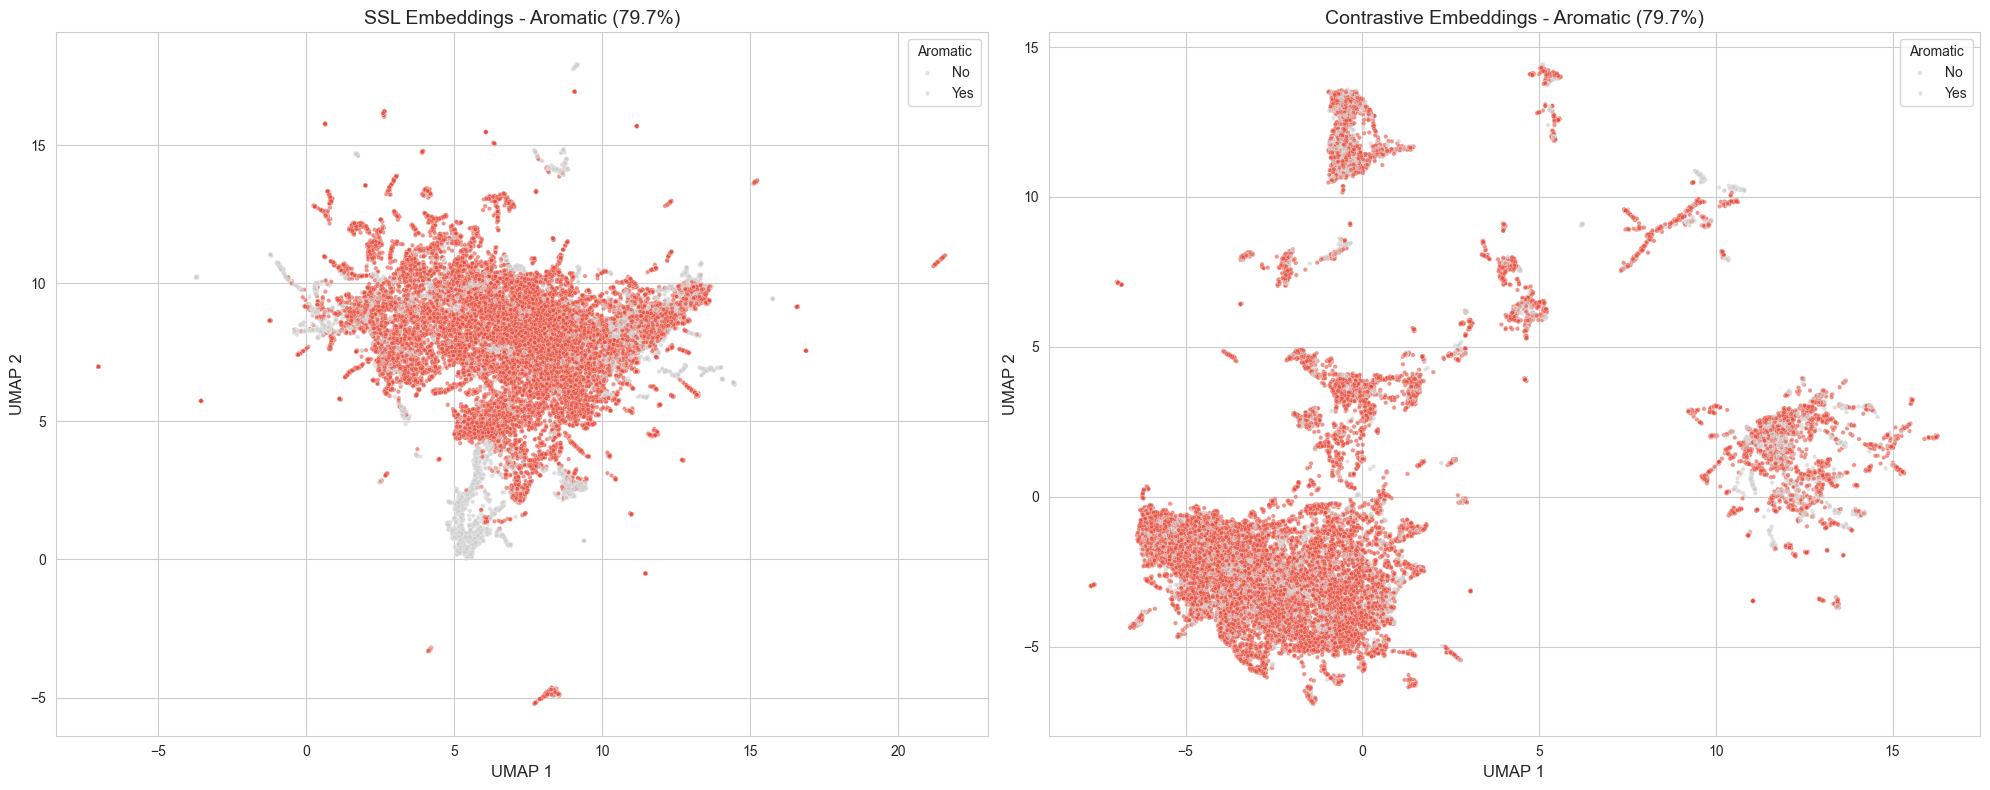

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# SSL embeddings
sns.scatterplot(
    data=df_sample,
    x='ssl_umap_1',
    y='ssl_umap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[0],
    legend='full'
)
axes[0].set_title(f'SSL Embeddings - Aromatic ({df_sample["aromatic"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)
axes[0].legend(title='Aromatic', labels=['No', 'Yes'])

# Contrastive embeddings
sns.scatterplot(
    data=df_sample,
    x='contrastive_umap_1',
    y='contrastive_umap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[1],
    legend='full'
)
axes[1].set_title(f'Contrastive Embeddings - Aromatic ({df_sample["aromatic"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)
axes[1].legend(title='Aromatic', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## Side-by-Side Comparison: Nitrogen Presence

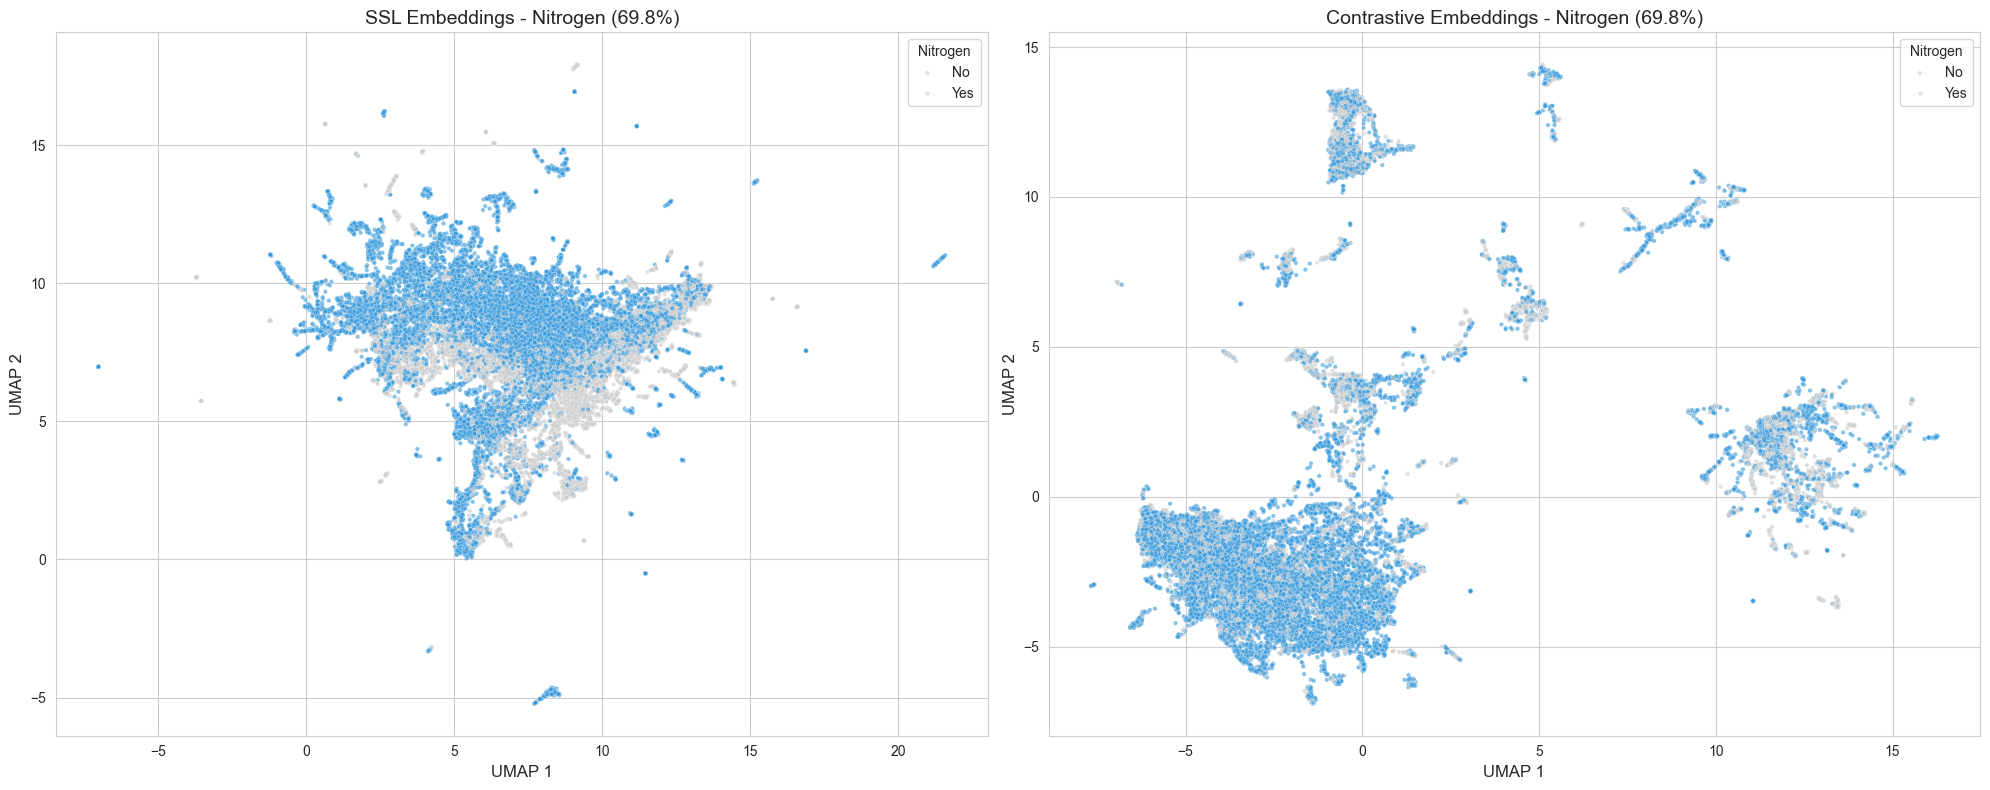

In [18]:
# Extract nitrogen presence from formula
df_sample['has_nitrogen'] = df_sample['formula'].str.contains('N', regex=False).fillna(False).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# SSL embeddings
sns.scatterplot(
    data=df_sample,
    x='ssl_umap_1',
    y='ssl_umap_2',
    hue='has_nitrogen',
    palette={0: '#cccccc', 1: '#3498db'},
    alpha=0.6,
    s=10,
    ax=axes[0],
    legend='full'
)
axes[0].set_title(f'SSL Embeddings - Nitrogen ({df_sample["has_nitrogen"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)
axes[0].legend(title='Nitrogen', labels=['No', 'Yes'])

# Contrastive embeddings
sns.scatterplot(
    data=df_sample,
    x='contrastive_umap_1',
    y='contrastive_umap_2',
    hue='has_nitrogen',
    palette={0: '#cccccc', 1: '#3498db'},
    alpha=0.6,
    s=10,
    ax=axes[1],
    legend='full'
)
axes[1].set_title(f'Contrastive Embeddings - Nitrogen ({df_sample["has_nitrogen"].sum() / len(df_sample) * 100:.1f}%)', fontsize=14)
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)
axes[1].legend(title='Nitrogen', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## Side-by-Side Comparison: Molecular Weight

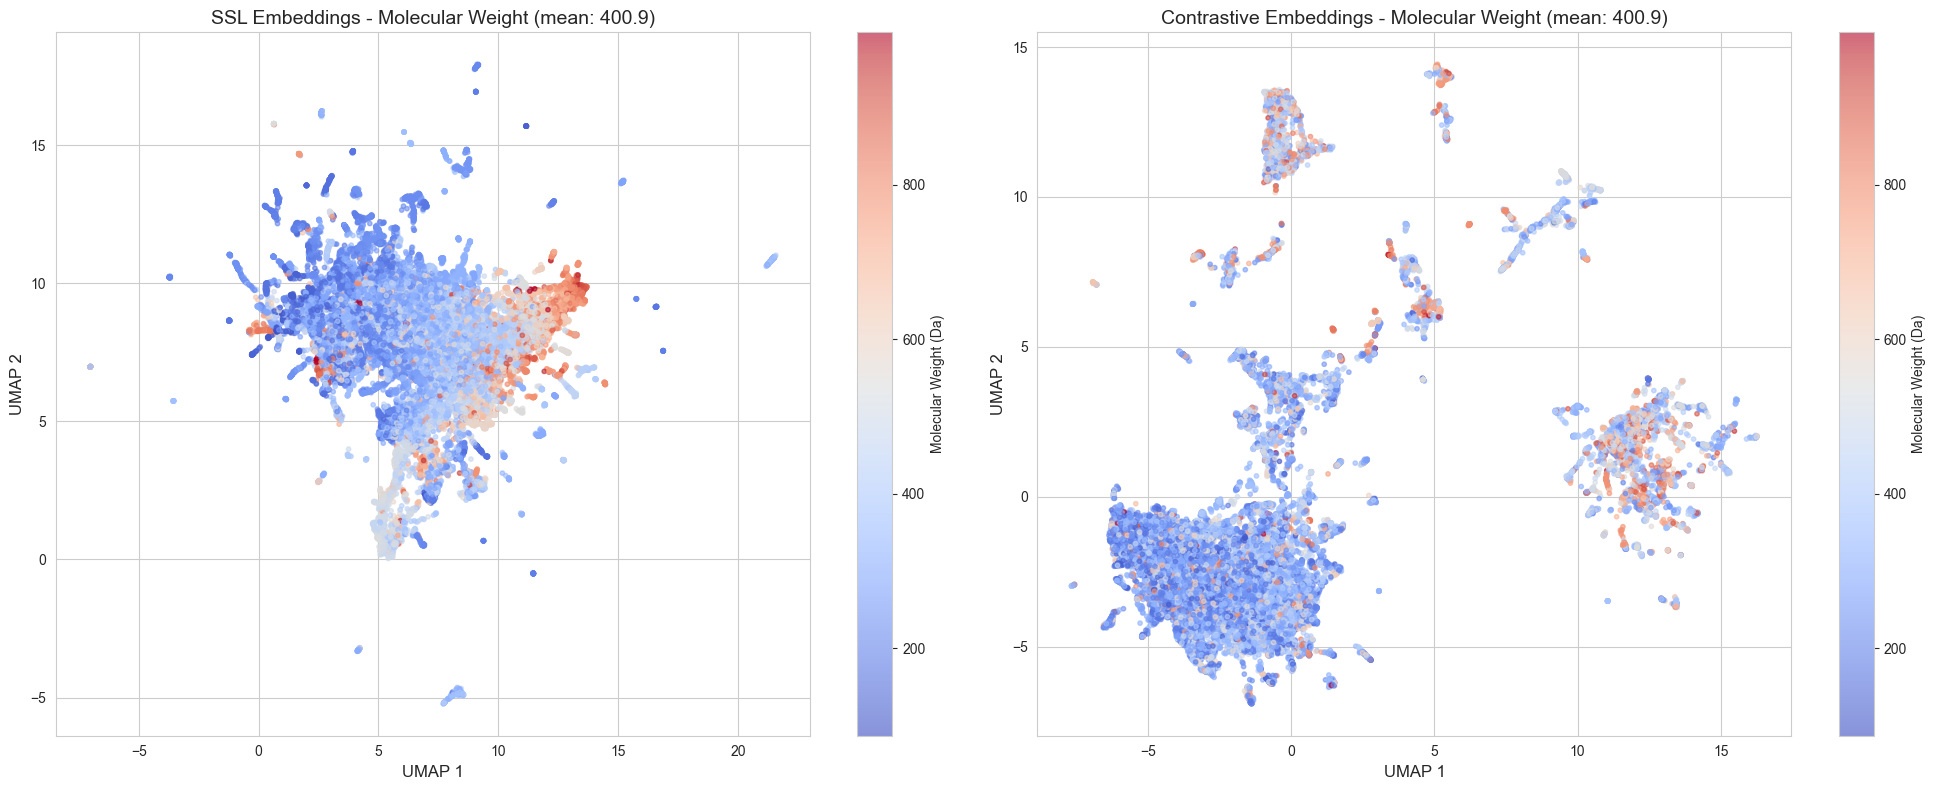

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# SSL embeddings
scatter1 = axes[0].scatter(
    df_sample['ssl_umap_1'],
    df_sample['ssl_umap_2'],
    c=df_sample['mol_weight'],
    cmap='coolwarm',
    alpha=0.6,
    s=10
)
axes[0].set_title(f'SSL Embeddings - Molecular Weight (mean: {df_sample["mol_weight"].mean():.1f})', fontsize=14)
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Molecular Weight (Da)')

# Contrastive embeddings
scatter2 = axes[1].scatter(
    df_sample['contrastive_umap_1'],
    df_sample['contrastive_umap_2'],
    c=df_sample['mol_weight'],
    cmap='coolwarm',
    alpha=0.6,
    s=10
)
axes[1].set_title(f'Contrastive Embeddings - Molecular Weight (mean: {df_sample["mol_weight"].mean():.1f})', fontsize=14)
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Molecular Weight (Da)')

plt.tight_layout()
plt.show()

## 4-Panel Overview Comparison

SSL (left) vs Contrastive (right) for key properties

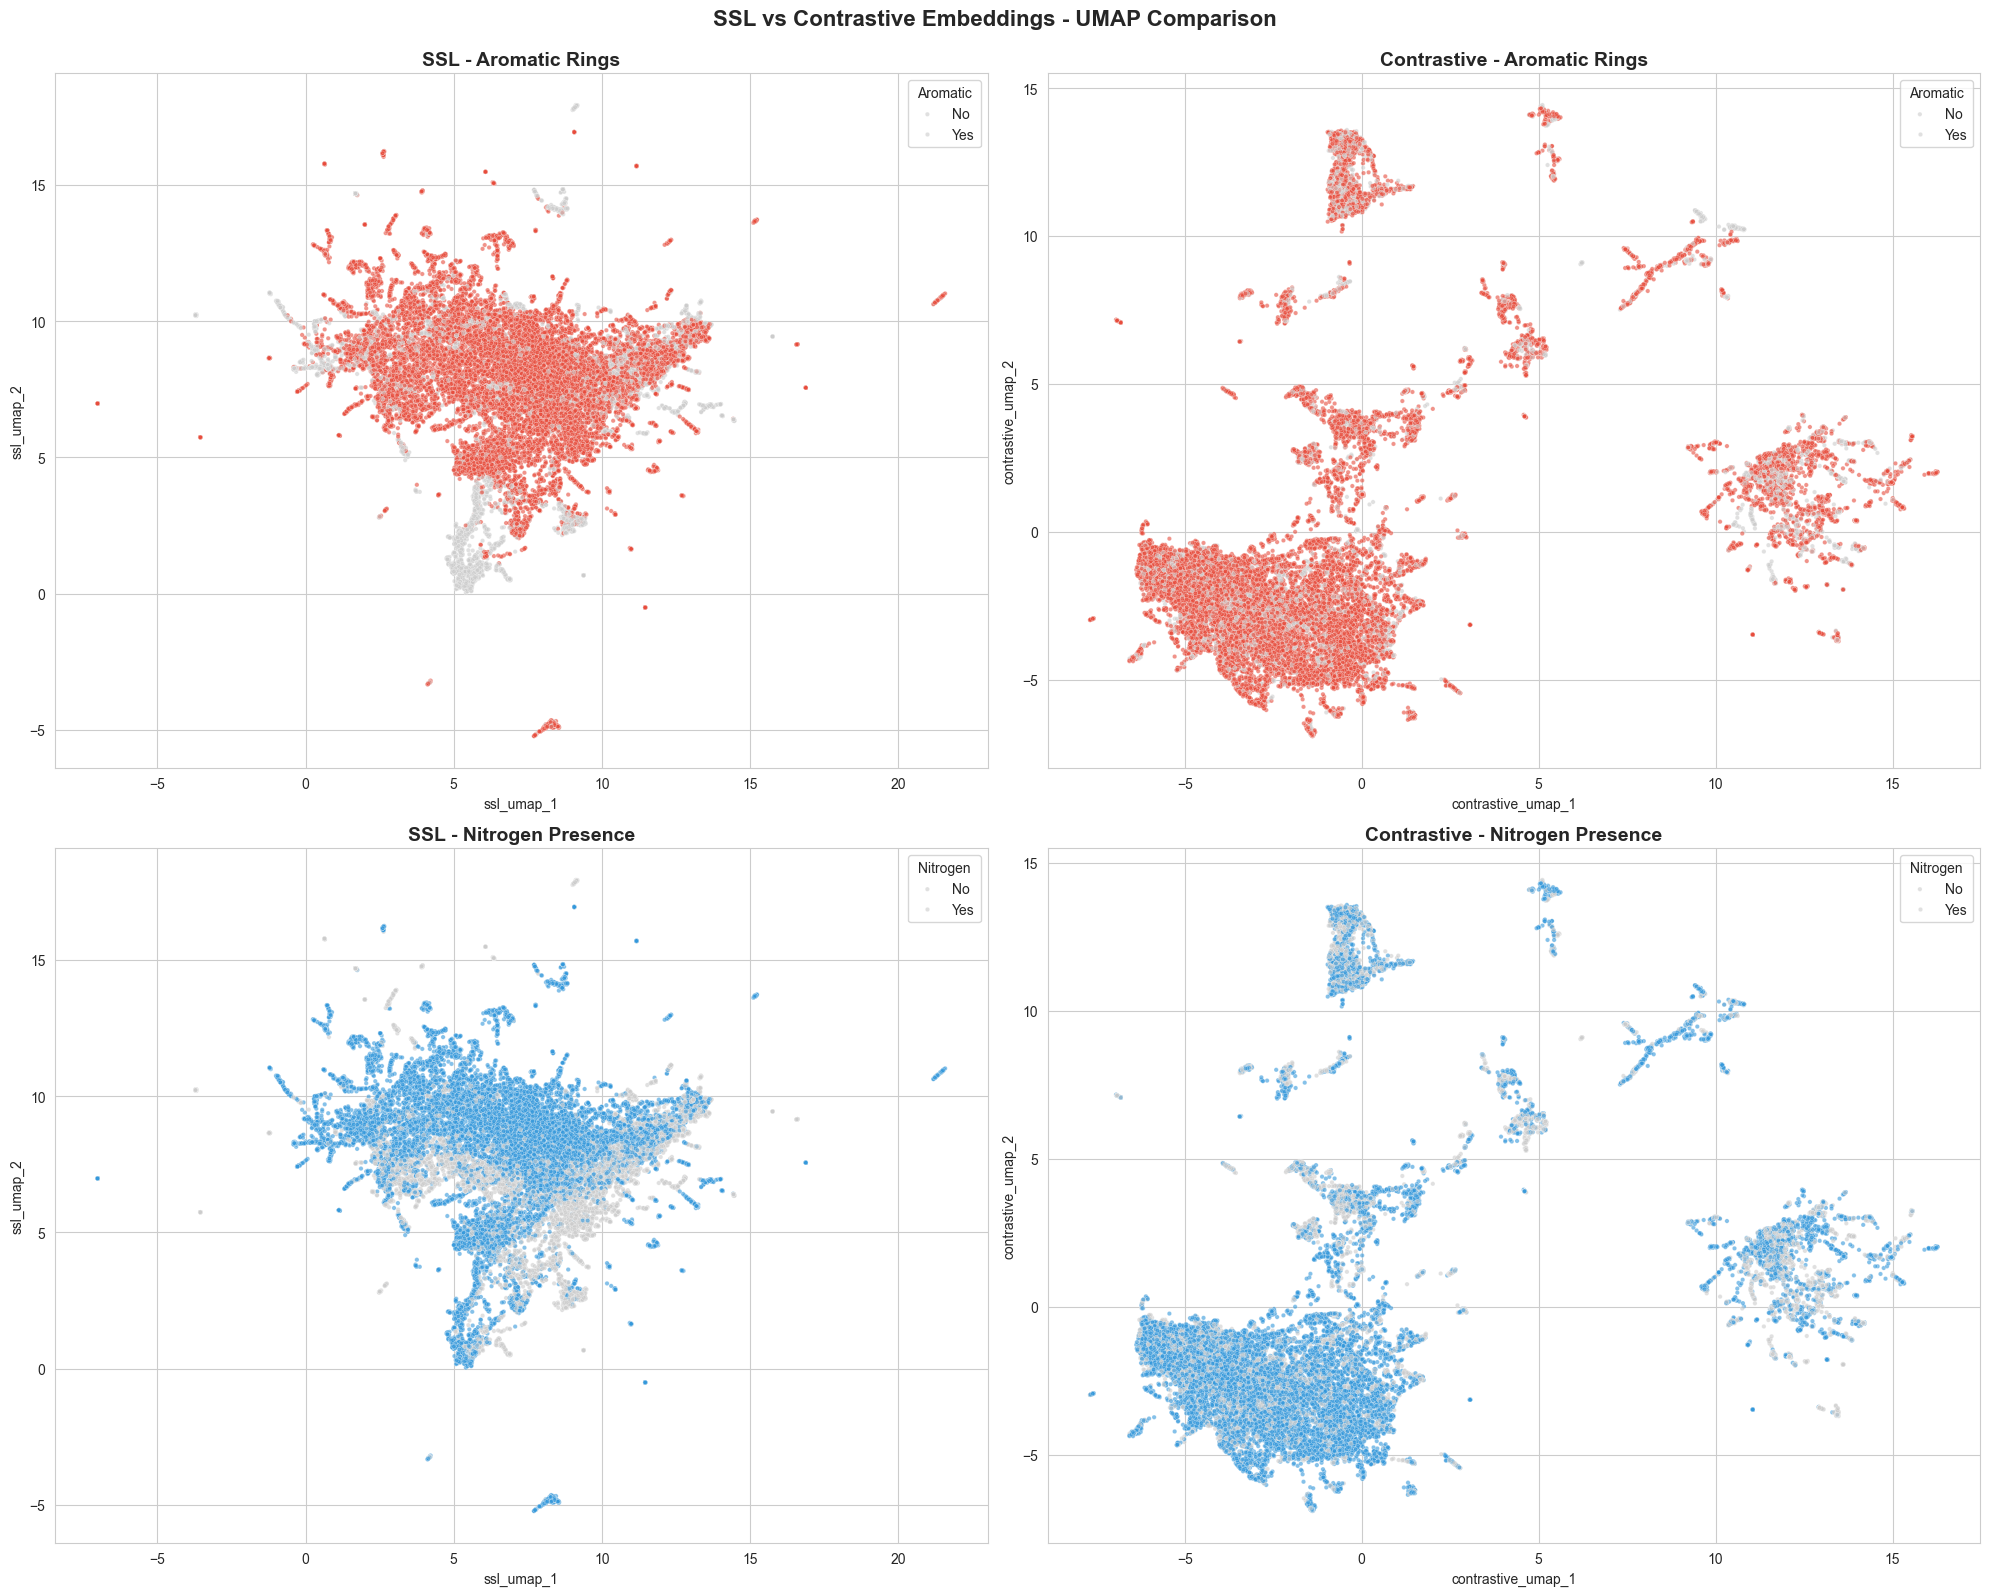

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Top-left: SSL - Aromatic
sns.scatterplot(
    data=df_sample,
    x='ssl_umap_1',
    y='ssl_umap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[0, 0],
    legend='full'
)
axes[0, 0].set_title('SSL - Aromatic Rings', fontsize=14, fontweight='bold')
axes[0, 0].legend(title='Aromatic', labels=['No', 'Yes'])

# Top-right: Contrastive - Aromatic
sns.scatterplot(
    data=df_sample,
    x='contrastive_umap_1',
    y='contrastive_umap_2',
    hue='aromatic',
    palette={0: '#cccccc', 1: '#e74c3c'},
    alpha=0.6,
    s=10,
    ax=axes[0, 1],
    legend='full'
)
axes[0, 1].set_title('Contrastive - Aromatic Rings', fontsize=14, fontweight='bold')
axes[0, 1].legend(title='Aromatic', labels=['No', 'Yes'])

# Bottom-left: SSL - Nitrogen
sns.scatterplot(
    data=df_sample,
    x='ssl_umap_1',
    y='ssl_umap_2',
    hue='has_nitrogen',
    palette={0: '#cccccc', 1: '#3498db'},
    alpha=0.6,
    s=10,
    ax=axes[1, 0],
    legend='full'
)
axes[1, 0].set_title('SSL - Nitrogen Presence', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Nitrogen', labels=['No', 'Yes'])

# Bottom-right: Contrastive - Nitrogen
sns.scatterplot(
    data=df_sample,
    x='contrastive_umap_1',
    y='contrastive_umap_2',
    hue='has_nitrogen',
    palette={0: '#cccccc', 1: '#3498db'},
    alpha=0.6,
    s=10,
    ax=axes[1, 1],
    legend='full'
)
axes[1, 1].set_title('Contrastive - Nitrogen Presence', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Nitrogen', labels=['No', 'Yes'])

# Add overall title
fig.suptitle('SSL vs Contrastive Embeddings - UMAP Comparison', fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Summary Statistics

In [23]:
print("="*60)
print("EMBEDDING COMPARISON SUMMARY")
print("="*60)
print(f"\nSample size: {len(df_sample):,}")
print(f"\nSSL Embeddings (pure pre-trained):")
print(f"  Shape: {ssl_embeddings.shape}")
print(f"  Mean: {ssl_embeddings.mean():.4f}")
print(f"  Std: {ssl_embeddings.std():.4f}")
print(f"\nContrastive Embeddings (fine-tuned):")
print(f"  Shape: {contrastive_embeddings.shape}")
print(f"  Mean: {contrastive_embeddings.mean():.4f}")
print(f"  Std: {contrastive_embeddings.std():.4f}")

if not are_identical:
    print(f"\nDifference between embeddings:")
    print(f"  Mean absolute difference: {diff.mean():.4f}")
    print(f"  Max absolute difference: {diff.max():.4f}")
    print(f"\n✅ Embeddings are DIFFERENT (as expected!)")
else:
    print(f"\n⚠️ WARNING: Embeddings are IDENTICAL!")
    
print("\nKey observations:")
print("  - SSL: Trained with mask_peak_hot (predict masked m/z)")
print("  - Contrastive: Fine-tuned with triplet loss (spectral similarity)")
print("  - Compare clustering patterns to see what each encodes")
print("="*60)

EMBEDDING COMPARISON SUMMARY

Sample size: 30,000

SSL Embeddings (pure pre-trained):
  Shape: (30000, 1024)
  Mean: 0.0019
  Std: 1.3475

Contrastive Embeddings (fine-tuned):
  Shape: (30000, 1024)
  Mean: 0.0087
  Std: 0.8684

Difference between embeddings:
  Mean absolute difference: 1.2575
  Max absolute difference: 16.4642

✅ Embeddings are DIFFERENT (as expected!)

Key observations:
  - SSL: Trained with mask_peak_hot (predict masked m/z)
  - Contrastive: Fine-tuned with triplet loss (spectral similarity)
  - Compare clustering patterns to see what each encodes
